In [442]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import linear_model

In [443]:
df_AQS=pd.read_csv('ds/LA_AQS_2023.csv')
df_manuoa=pd.read_csv('ds/ManuaLoa_CO2.csv')

In [444]:
df_AQS.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [445]:
df_manuoa.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [446]:
df_o3 = df_AQS.loc[df_AQS['Parameter Name']=='Ozone']
df_o3_hourly=df_o3.loc[df_o3['Duration Description']=='1 HOUR']

# Date (Local), AQI
df_o3_hourly['Date (Local)']=pd.to_datetime(df_o3_hourly['Date (Local)'])
df_o3_hourly.head()

/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_16910/435737406.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_hourly['Date (Local)']=pd.to_datetime(df_o3_hourly['Date (Local)'])


,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
228,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
271,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [447]:
df_no2 = df_AQS.loc[df_AQS['Parameter Name']=='Nitrogen dioxide (NO2)']
df_no2_hourly=df_no2.loc[df_no2['Duration Description']=='1 HOUR']

# Date (Local), AQI
df_no2_hourly['Date (Local)']=pd.to_datetime(df_no2_hourly['Date (Local)'])
df_no2_hourly.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
19,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
29,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
41,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
44,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,20,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [448]:
# converts ppm to ppb

df_o3_hourly.loc[:, 'Arithmetic Mean']=df_o3_hourly['Arithmetic Mean'] * 1000

In [449]:
df_o3_hourly['Date (Local)'] = pd.to_datetime(df_o3_hourly['Date (Local)'])
df_no2_hourly['Date (Local)'] = pd.to_datetime(df_no2_hourly['Date (Local)'])

merged_df = pd.merge(df_o3_hourly, df_no2_hourly, on=['Date (Local)'], how='inner', suffixes=('_o3', '_no2'))
merged_df.head()

/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_16910/2221377621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_hourly['Date (Local)'] = pd.to_datetime(df_o3_hourly['Date (Local)'])


,State Code_o3,County Code_o3,Site Number_o3,Parameter Code_o3,POC_o3,Latitude_o3,Longitude_o3,Datum_o3,Parameter Name_o3,Duration Description_o3,...,AQI_no2,Daily Criteria Indicator_no2,Tribe Name_no2,State Name_no2,County Name_no2,City Name_no2,Local Site Name_no2,Address_no2,MSA or CBSA Name_no2,Data Source_no2
0,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,20,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


# Linear modeling in python – EPA AQS Data

## 1. Fit a line* between O3 and NO2. Train on 80% of the data, test on 20%.

<Axes: xlabel='Arithmetic Mean_o3', ylabel='Arithmetic Mean_no2'>

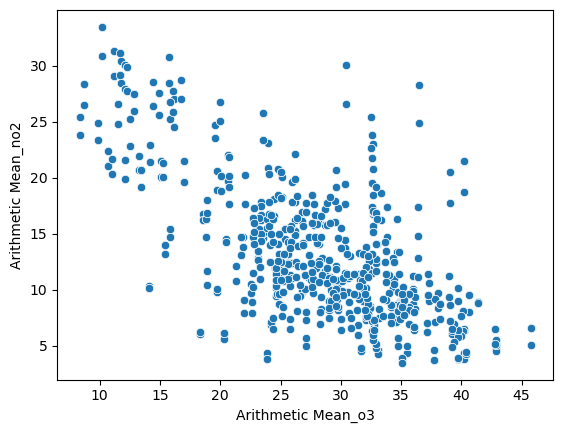

In [452]:
# Scatter plot:

sns.scatterplot(data=merged_df, x="Arithmetic Mean_o3", y="Arithmetic Mean_no2")

In [453]:
xVal = np.array(merged_df['Arithmetic Mean_o3']).reshape((-1, 1))
yVal = np.array(merged_df['Arithmetic Mean_no2'])

reg = linear_model.LinearRegression()
reg.fit(xVal,yVal)

LinearRegression()

### Fitted line:

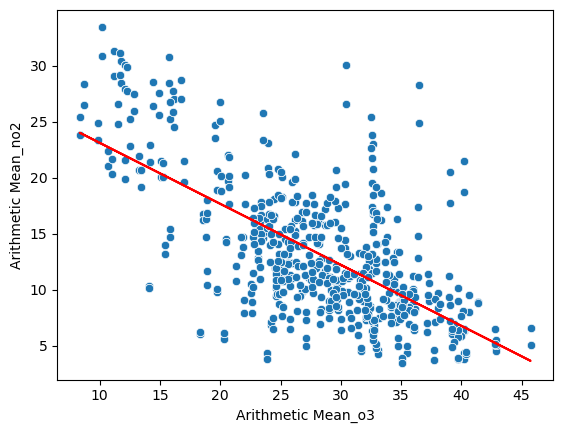

In [455]:
yPred = reg.predict(xVal)

merged_df['yPred'] = yPred
sns.scatterplot(data=merged_df, x="Arithmetic Mean_o3", y="Arithmetic Mean_no2")
plt.plot(merged_df['Arithmetic Mean_o3'], merged_df['yPred'], color='r')

In [456]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(xVal, yVal, test_size=0.2)

In [457]:
reg2 = linear_model.LinearRegression()
reg2.fit(X_train,y_train)
print("Coefficients: \n", reg2.coef_)
print("Intercept: \n", reg2.intercept_)

Coefficients: 
 [-0.54361787]
Intercept: 
 28.438169550631386


In [458]:
X_test.ravel()

array([35.667, 29.792, 32.667, 26.833, 33.125, 16.125, 40.375, 31.708,
       26.875, 39.208, 18.792, 38.958, 41.381, 26.208, 40.25 , 40.25 ,
       15.75 , 29.333, 29.625, 25.625, 21.708, 42.875, 24.458, 32.583,
       31.708, 34.333, 27.667, 31.125, 40.25 , 25.625, 34.792, 10.708,
       32.   , 12.083, 35.056, 25.   , 25.333, 14.083, 15.792, 40.   ,
       19.75 , 29.75 , 28.958, 26.167, 27.955, 34.167, 32.917,  8.667,
       34.667, 18.583, 37.25 , 20.   , 21.875, 23.375, 38.958, 36.125,
       42.875, 24.083, 31.875, 31.5  , 21.333, 37.292, 28.667, 17.   ,
       24.792, 34.333, 33.833, 27.955, 26.167, 29.   , 24.167, 35.125,
       27.792, 34.833, 39.208, 19.583, 28.333, 38.958, 27.588, 32.25 ,
       36.083, 30.375, 45.75 , 28.958, 38.25 , 36.5  , 15.042, 31.542,
       11.75 , 28.167, 22.542, 22.667, 28.167, 14.917, 35.667, 33.958,
       28.136, 30.833, 26.792, 25.333, 36.5  , 27.375, 22.042, 28.333,
       24.042, 36.   , 22.833, 28.333, 36.5  , 28.136, 28.333, 12.083,
      

In [459]:
#Plot Test Data
df_test = pd.DataFrame({'O3' : X_test.ravel(), 'NO2' : y_test.ravel()})
df_test['NO2Pred'] = reg2.predict(X_test)

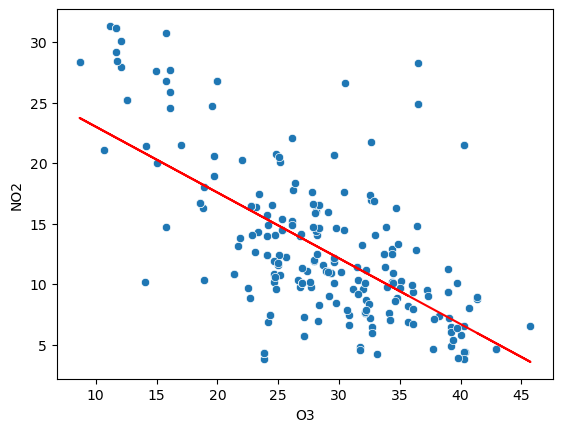

In [460]:
sns.scatterplot(data=df_test, x="O3", y="NO2")
plt.plot(df_test['O3'], df_test['NO2Pred'], color='r')

## 2. What is your test error? (Be sure to include units and the metric you used).

In [462]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [482]:
mse = mean_squared_error(df_test['NO2'], df_test['NO2Pred'])
mae = mean_absolute_error(df_test['NO2'], df_test['NO2Pred'])

print(f"Test MSE: {mse} ppb^2")
print(f"Test MAE: {mae} ppb")
print(f"Test RMSE: {np.sqrt(mse)} ppb")

Test MSE: 25.41017577793046 ppb^2
Test MAE: 3.7292755882503945 ppb
Test RMSE: 5.040850699825423 ppb


## 3. Do you think a linear model performs well? Why/why not?

The test MAE being 3.7 shows that the linear model's prediction is onlyoff by around 3.626 ppb from the true value. As for the test MSE being 25.4 ppb^2, this shows that there is some deviation within our dataset. However, looking at our RMSE as well (5.0 ppb), it shows that our error is relatively small because it is only a little higher than our MASE and our model has not many outliers. Based on these values, I would say that our linear model performs well.


# Mauna Loa CO2

## 1. Fit a linear model* of CO2 vs. time (decimal date) using data before 2000.

In [486]:
df_manuoa.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [488]:
# Filter for dates less than (before than) 2000
df_manuoa_bf2020 = df_manuoa[(df_manuoa['decimal date'] <= 2000.0)]

df_manuoa_bf2020.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


<Axes: xlabel='decimal date', ylabel='average'>

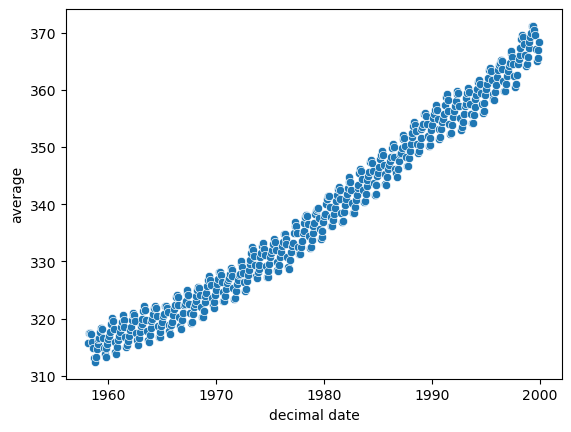

In [490]:
# Scatter plot:

sns.scatterplot(data=df_manuoa_bf2020, y="average", x="decimal date")

In [491]:
from sklearn.linear_model import LinearRegression

In [494]:
xVal = np.array(df_manuoa_bf2020['decimal date']).reshape((-1, 1))
yVal = np.array(df_manuoa_bf2020['average'])

reg = linear_model.LinearRegression()
reg.fit(xVal,yVal)

LinearRegression()

In [496]:
print(f"CO2 Growth Rate: {model.coef_[0]:.4f} ppm/year")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Model R_squared Score: {model.score(X, y):.4f}")

CO2 Growth Rate: 1.3233 ppm/year
Intercept: -2280.5911
Model R_squared Score: 0.9210


/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_16910/2767759605.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manuoa_bf2020['yPred'] = yPred


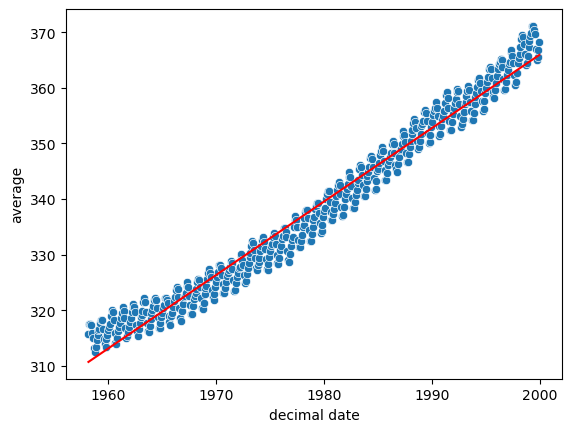

In [498]:
yPred = reg.predict(xVal)

df_manuoa_bf2020['yPred'] = yPred
sns.scatterplot(data=df_manuoa_bf2020, x="decimal date", y="average")
plt.plot(df_manuoa_bf2020['decimal date'], df_manuoa_bf2020['yPred'], color='r')

## 2. Test your linear model on data after 2000. How well does it perform?

In [501]:
# Filter for dates greater than (after than) 2000
df_manuoa_af2020 = df_manuoa[(df_manuoa['decimal date'] > 2000.0)]


In [503]:
train_df = df_manuoa_bf2020
test_df = df_manuoa_af2020


In [505]:
X_train = train_df[['decimal date']].values
y_train = train_df['average'].values

X_test = test_df[['decimal date']].values
y_test = test_df['average'].values


In [507]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [509]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

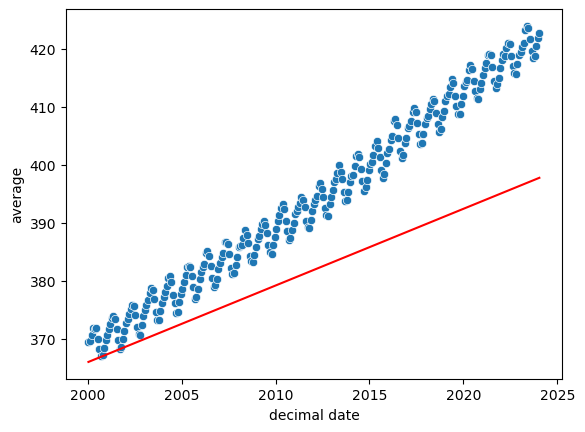

In [511]:
#Plot Test Data

df_test = pd.DataFrame({'decimal date' : X_test.ravel(), 'average' : y_test.ravel()})
df_test['pred'] = model.predict(X_test)
sns.scatterplot(data=df_test, x="decimal date", y="average")
plt.plot(df_test['decimal date'], df_test['pred'], color='r')

### BF 2000 (Training DS)

In [514]:
from sklearn.metrics import r2_score

In [516]:
print(f"R_squared score: {r2_score(y_train, y_train_pred)}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred)}")

R_squared score: 0.9717371058681556
MSE: 7.428737725453339


### AF 2000 (Testing DS)

In [519]:
print(f"R_squared score: {r2_score(y_test, y_test_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred)}")

R_squared score: 0.19001653191038226
MSE: 200.24617110972434


## 3. Do you think a linear model performs well? Why/why not?

From the R^2 values between out training and testing dataset, the difference is pretty large with our training being at 0.97 and testing being at 0.19, which indicates that with our testing data, only 19% of the variance is captures and the error is also very high with an MSE of 200.2. For our training data, the MSE is at 7.42, which is a lot lower. This shows that with our model, there is underfitting and that the model does not perform well. 